# Phase 1 — Data Pipeline

Pulls two years of GB market data from public APIs and saves to `data/raw/`.

| Step | Source | Output file |
|------|--------|-------------|
| 1 | Elexon BMRS | `elexon_da_prices.parquet` — half-hourly day-ahead prices |
| 2 | Elexon BMRS | `elexon_sp_prices.parquet` — half-hourly System Price (cash-out) |
| 3 | NESO Data Portal | `neso_eac_clearing.parquet` — EAC ancillary clearing by product |
| 4 | forward_uk.xlsx (Priority 1) | `forwards.parquet` — GB baseload + peak forward curve (UBLIMc1–36, UPLMc1–36) |

**Run cells top to bottom.** Step 3 may return empty if NESO resource IDs have changed — see note in that cell.

In [1]:
import sys, os

# Resolve project root (one level up from notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)

import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'requests', 'pandas', 'pyarrow', 'matplotlib',
                'python-dateutil', 'openpyxl', '--quiet'])

Project root: g:\My Drive\Research\bess_project


CompletedProcess(args=['c:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', 'requests', 'pandas', 'pyarrow', 'matplotlib', 'python-dateutil', 'openpyxl', '--quiet'], returncode=0)

In [2]:
from datetime import date
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

START = date(2024, 4, 1)   # 2 years of history for calibration
END   = date(2026, 4, 25)

RAW_DIR = Path(PROJECT_ROOT) / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f'Fetching: {START} to {END}')
print(f'Output:   {RAW_DIR}')

Fetching: 2024-04-01 to 2026-04-25
Output:   g:\My Drive\Research\bess_project\data\raw


## Step 1 — Elexon day-ahead prices (MID)

Market Index Data — volume-weighted N2EX + EPEX half-hourly index.  
Public API, no credentials required.  
**Expected**: ~35,000 rows (2 years x 365 days x 48 HH periods)

In [3]:
from src.data.fetch_elexon import fetch_mid_range

da_path = RAW_DIR / 'elexon_da_prices.parquet'
df_da   = fetch_mid_range(START, END, out_path=da_path)

print(f'Rows: {len(df_da):,}')
df_da.head(8)

2026-04-29 20:42:09,498 INFO Fetching MID (day-ahead) from 2024-04-01 to 2026-04-25 (755 days)
2026-04-29 20:42:09,894 INFO MID progress: 1/755 days through 2024-04-01, 96 rows collected, 0.4s elapsed
2026-04-29 20:42:18,417 INFO MID progress: 25/755 days through 2024-04-25, 2396 rows collected, 8.9s elapsed
2026-04-29 20:42:27,223 INFO MID progress: 50/755 days through 2024-05-20, 4791 rows collected, 17.7s elapsed
2026-04-29 20:42:36,024 INFO MID progress: 75/755 days through 2024-06-14, 7186 rows collected, 26.5s elapsed
2026-04-29 20:42:44,981 INFO MID progress: 100/755 days through 2024-07-09, 9584 rows collected, 35.5s elapsed
2026-04-29 20:42:54,075 INFO MID progress: 125/755 days through 2024-08-03, 11980 rows collected, 44.6s elapsed
2026-04-29 20:43:04,338 INFO MID progress: 150/755 days through 2024-08-28, 14377 rows collected, 54.8s elapsed
2026-04-29 20:43:14,055 INFO MID progress: 175/755 days through 2024-09-22, 16776 rows collected, 64.5s elapsed
2026-04-29 20:43:32,511

Rows: 72,258


,settlement_date,settlement_period,price_gbp_mwh,volume_mwh,data_provider
0,2024-04-01,1,27.54,860.0,APXMIDP
1,2024-04-01,1,0.00,0.0,N2EXMIDP
2,2024-04-01,2,26.46,974.3,APXMIDP
3,2024-04-01,2,0.00,0.0,N2EXMIDP
4,2024-04-01,3,25.19,749.0,APXMIDP
5,2024-04-01,3,0.00,0.0,N2EXMIDP
6,2024-04-01,4,33.60,745.3,APXMIDP
7,2024-04-01,4,0.00,0.0,N2EXMIDP


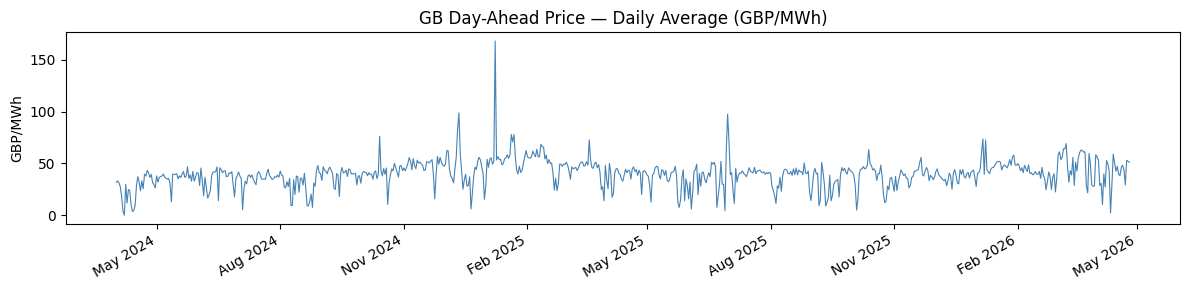

2025 DA:  mean=40.2  std=49.1  min=-102.9  max=1352.9
Negative price HHs: 1043 (model needs arithmetic OU, not log-normal)


In [4]:
if not df_da.empty:
    daily = df_da.groupby('settlement_date')['price_gbp_mwh'].mean()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(daily.index, daily.values, lw=0.8, color='steelblue')
    ax.set(title='GB Day-Ahead Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    y2025 = df_da[df_da['settlement_date'].dt.year == 2025]['price_gbp_mwh']
    print(f'2025 DA:  mean={y2025.mean():.1f}  std={y2025.std():.1f}  '
          f'min={y2025.min():.1f}  max={y2025.max():.1f}')
    print(f'Negative price HHs: {(df_da["price_gbp_mwh"] < 0).sum()} '
          '(model needs arithmetic OU, not log-normal)')

## Step 2 — Elexon System Price (imbalance / cash-out)

System Price is the cash-out price for energy imbalance.  
Used to compute the DA-SP basis delta_t for OU+jump imbalance calibration.  
**Expected**: ~35,000 rows with `system_sell_price`, `system_buy_price`, `net_imbalance_volume`

In [5]:
from src.data.fetch_elexon import fetch_system_prices_range

sp_path = RAW_DIR / 'elexon_sp_prices.parquet'
df_sp   = fetch_system_prices_range(START, END, out_path=sp_path)

print(f'Rows: {len(df_sp):,}')
df_sp.head(6)

2026-04-29 20:49:16,895 INFO Fetching System Prices from 2024-04-01 to 2026-04-25 (755 days)
2026-04-29 20:49:17,515 INFO System price progress: 1/755 days through 2024-04-01, 48 rows collected, 0.6s elapsed
2026-04-29 20:49:34,340 INFO System price progress: 25/755 days through 2024-04-25, 1200 rows collected, 17.5s elapsed
2026-04-29 20:49:51,207 INFO System price progress: 50/755 days through 2024-05-20, 2400 rows collected, 34.3s elapsed
2026-04-29 20:50:08,155 INFO System price progress: 75/755 days through 2024-06-14, 3600 rows collected, 51.3s elapsed
2026-04-29 20:50:25,704 INFO System price progress: 100/755 days through 2024-07-09, 4800 rows collected, 68.8s elapsed
2026-04-29 20:50:42,162 INFO System price progress: 125/755 days through 2024-08-03, 6000 rows collected, 85.3s elapsed
2026-04-29 20:50:58,938 INFO System price progress: 150/755 days through 2024-08-28, 7200 rows collected, 102.0s elapsed
2026-04-29 20:51:17,367 INFO System price progress: 175/755 days through 2

Rows: 36,240


,settlement_date,settlement_period,system_sell_price,system_buy_price,net_imbalance_volume,system_price
0,2024-04-01,1,25.050000,25.050000,-339.064440,25.050000
1,2024-04-01,2,25.650000,25.650000,-230.773426,25.650000
2,2024-04-01,3,23.990000,23.990000,-66.013667,23.990000
3,2024-04-01,4,76.000000,76.000000,143.783160,76.000000
4,2024-04-01,5,73.384327,73.384327,27.688429,73.384327
5,2024-04-01,6,18.170000,18.170000,-151.031493,18.170000


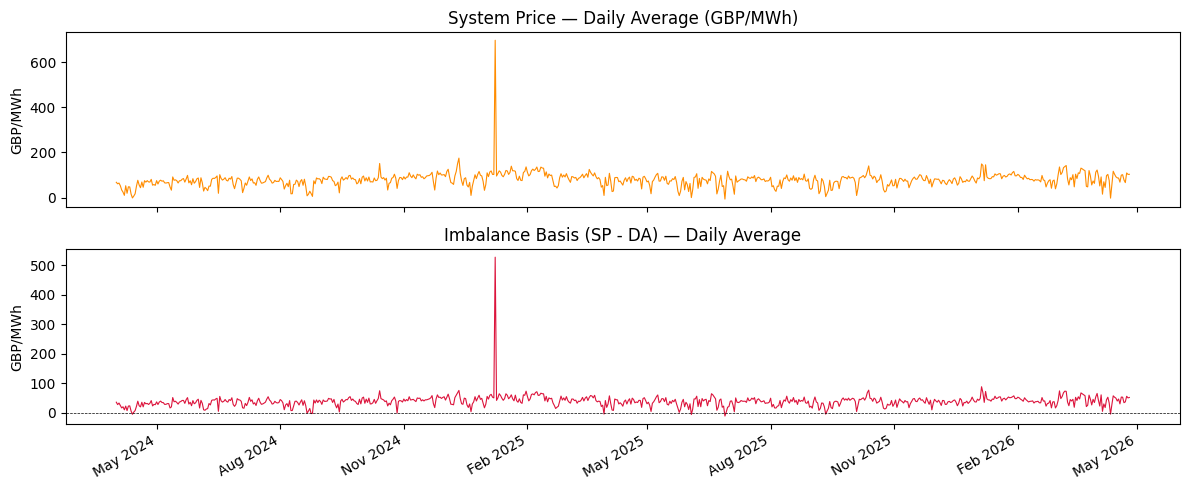

Imbalance basis stats (GBP/MWh):
count    72258.0
mean        39.5
std         65.5
min       -508.2
25%         -0.7
50%         25.2
75%         82.7
max       2900.0
Name: imbalance_basis, dtype: float64
Jump HHs (|basis|>100): 11259


In [6]:
if not df_sp.empty and not df_da.empty:
    merged = df_da[['settlement_date','settlement_period','price_gbp_mwh']].merge(
        df_sp[['settlement_date','settlement_period','system_price','net_imbalance_volume']],
        on=['settlement_date','settlement_period'], how='inner'
    )
    merged['imbalance_basis'] = merged['system_price'] - merged['price_gbp_mwh']

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(merged.groupby('settlement_date')['system_price'].mean(), lw=0.8, color='darkorange')
    axes[0].set(title='System Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    axes[1].plot(merged.groupby('settlement_date')['imbalance_basis'].mean(), lw=0.8, color='crimson')
    axes[1].axhline(0, color='k', lw=0.5, ls='--')
    axes[1].set(title='Imbalance Basis (SP - DA) — Daily Average', ylabel='GBP/MWh')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    print('Imbalance basis stats (GBP/MWh):')
    print(merged['imbalance_basis'].describe().round(1))
    print(f'Jump HHs (|basis|>100): {(merged["imbalance_basis"].abs()>100).sum()}')

## Step 3 — NESO EAC ancillary clearing

DC / DM / DR clearing prices by EFA block. QR from December 2024. BR from March 2024.

> **If this returns empty:** NESO reorganised dataset URLs in late 2024.  
> Go to https://api.nationalgrideso.com, search the product name (e.g. *Dynamic Containment EFA*),  
> copy the resource ID from the dataset URL, update `RESOURCE_IDS` in `src/data/fetch_neso.py`.  
> Fallback: download CSV manually, then `pd.read_csv('dc.csv').to_parquet('data/raw/neso_eac_clearing.parquet')`

In [7]:
from src.data.fetch_neso import fetch_all_ancillary

anc_path = RAW_DIR / 'neso_eac_clearing.parquet'
df_anc   = fetch_all_ancillary(START.isoformat(), END.isoformat(), out_path=anc_path)

print(f'Rows: {len(df_anc):,}')
if not df_anc.empty:
    print(df_anc.groupby('product')['clearing_price_gbp_mwh']
               .agg(['count','mean','min','max']).round(2))
else:
    print('Empty — update NESO resource IDs in src/data/fetch_neso.py')
    print('See: https://api.nationalgrideso.com')

2026-04-29 20:55:53,419 INFO Fetching DC_Low (resource c5018520-1e40-4c29-9b96-f9a53af0bda1)
2026-04-29 20:55:53,580 WARNING Attempt 1 failed: HTTPSConnectionPool(host='api.nationalgrideso.com', port=443): Max retries exceeded with url: /api/3/action/datastore_search?resource_id=c5018520-1e40-4c29-9b96-f9a53af0bda1&limit=100000 (Caused by NameResolutionError("HTTPSConnection(host='api.nationalgrideso.com', port=443): Failed to resolve 'api.nationalgrideso.com' ([Errno 11001] getaddrinfo failed)")) — retrying
2026-04-29 20:55:55,582 WARNING Attempt 2 failed: HTTPSConnectionPool(host='api.nationalgrideso.com', port=443): Max retries exceeded with url: /api/3/action/datastore_search?resource_id=c5018520-1e40-4c29-9b96-f9a53af0bda1&limit=100000 (Caused by NameResolutionError("HTTPSConnection(host='api.nationalgrideso.com', port=443): Failed to resolve 'api.nationalgrideso.com' ([Errno 11001] getaddrinfo failed)")) — retrying
2026-04-29 20:55:59,591 WARNING CKAN fetch failed for c5018520-1e

Rows: 757
         count  mean    min    max
product                           
BR         152  0.34   0.00   7.50
DC         151  1.97  -1.29   9.62
DM         151  6.24  -1.72  14.18
DR         151 -5.78 -15.14  19.25
QR         152  4.62   0.00  20.38


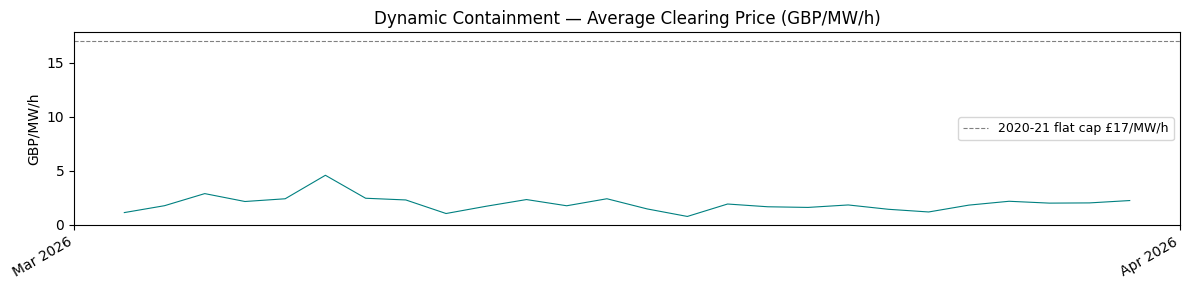

In [8]:
if not df_anc.empty and 'DC' in df_anc['product'].values:
    dc_daily = df_anc[df_anc['product']=='DC'].groupby('date')['clearing_price_gbp_mwh'].mean()
    fig, ax  = plt.subplots(figsize=(12, 3))
    ax.plot(dc_daily.index, dc_daily.values, lw=0.8, color='teal')
    ax.axhline(17, color='gray', lw=0.8, ls='--', label='2020-21 flat cap £17/MW/h')
    ax.set(title='Dynamic Containment — Average Clearing Price (GBP/MW/h)', ylabel='GBP/MW/h')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Step 4 — Forward curve

Loaded from **`data/raw/forward_uk.xlsx`** (Priority 1 source).

- Base sheet: `UBLIMc1`–`UBLIMc36` — GB baseload, monthly tenors 1–36 m forward
- Peak sheet: `UPLMc1`–`UPLMc36`  — GB peak, monthly tenors 1–36 m forward

**To refresh:** drop an updated `forward_uk.xlsx` into `data/raw/` and re-run this cell.

**Fallback:** `python -m src.data.fetch_forwards --source ice --file <path>` or `--source eex`

2026-04-29 20:59:35,713 INFO Loading forward UK workbook: g:\My Drive\Research\bess_project\data\raw\forward_uk.xlsx
2026-04-29 20:59:44,159 INFO forward_uk: 51960 rows, 830 unique dates, baseload/peak split: {'baseload': 29880, 'peak': 22080}


Forward curve: 51,960 rows
Date range:   2023-01-02 -> 2026-03-06
Contracts:    72 ({'baseload': 29880, 'peak': 22080})


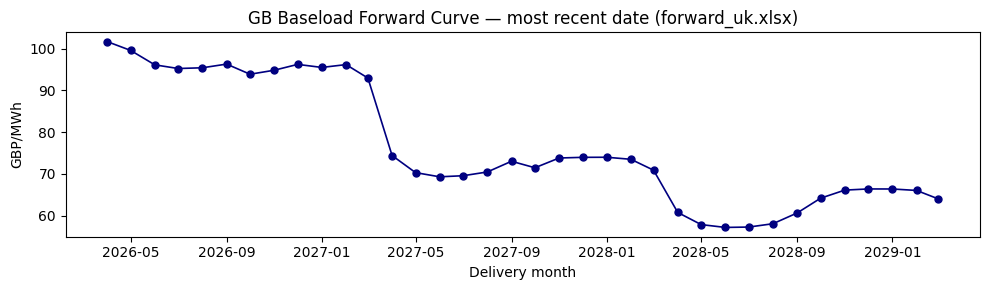

,contract,delivery_start,price_gbp_mwh
51888,UBLIMc1,2026-04-01,101.71
51899,UBLIMc2,2026-05-01,99.60
51910,UBLIMc3,2026-06-01,96.14
51918,UBLIMc4,2026-07-01,95.26
51919,UBLIMc5,2026-08-01,95.44
51920,UBLIMc6,2026-09-01,96.32
51921,UBLIMc7,2026-10-01,93.89
51922,UBLIMc8,2026-11-01,94.85


In [10]:
from src.data.fetch_forwards import load_forward_uk_export

fwd_path = RAW_DIR / 'forwards.parquet'
df_fwd   = load_forward_uk_export(RAW_DIR / 'forward_uk.xlsx')
df_fwd.to_parquet(fwd_path, index=False)

print(f'Forward curve: {len(df_fwd):,} rows')
print(f'Date range:   {df_fwd.as_of_date.min().date()} -> {df_fwd.as_of_date.max().date()}')
print(f'Contracts:    {df_fwd.contract.nunique()} ({df_fwd.groupby("type").size().to_dict()})')

bl = df_fwd[(df_fwd.type=='baseload') & (df_fwd.as_of_date==df_fwd.as_of_date.max())].sort_values('delivery_start')
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(bl['delivery_start'], bl['price_gbp_mwh'], 'o-', color='navy', ms=5, lw=1.2)
ax.set(title='GB Baseload Forward Curve — most recent date (forward_uk.xlsx)',
       ylabel='GBP/MWh', xlabel='Delivery month')
plt.tight_layout(); plt.show()
display(bl[['contract','delivery_start','price_gbp_mwh']].head(8))

## Validation Summary

In [11]:
print('=' * 55)
print('PHASE 1 VALIDATION SUMMARY')
print('=' * 55)

checks = {
    'elexon_da_prices.parquet':  100,
    'elexon_sp_prices.parquet':  100,
    'neso_eac_clearing.parquet':   0,
    'forwards.parquet':           72,
}

all_ok = True
for name, min_rows in checks.items():
    path = RAW_DIR / name
    if path.exists():
        n   = len(pd.read_parquet(path))
        ok  = n >= min_rows
        sym = 'OK  ' if ok else 'WARN'
        print(f'  [{sym}]  {name}: {n:,} rows')
        if not ok: all_ok = False
    else:
        print(f'  [FAIL]  {name}: MISSING'); all_ok = False

# Calibration spot-check
da_file = RAW_DIR / 'elexon_da_prices.parquet'
if da_file.exists():
    df_chk = pd.read_parquet(da_file)
    if not df_chk.empty:
        m25 = df_chk[df_chk['settlement_date'].dt.year==2025]['price_gbp_mwh'].mean()
        neg = (df_chk['price_gbp_mwh'] < 0).sum()
        print(f'\n  DA mean 2025:  £{m25:.1f}/MWh  (SS anchor: £76.7)')
        print(f'  Negative HHs:  {neg}  (arithmetic OU required, not log-normal)')

print('\nRESULT:', 'All files present — ready for Phase 2 calibration'
      if all_ok else 'Some files missing — see notes above')
print('Next: notebooks/02_calibration.ipynb')

PHASE 1 VALIDATION SUMMARY
  [OK  ]  elexon_da_prices.parquet: 72,258 rows
  [OK  ]  elexon_sp_prices.parquet: 36,240 rows
  [OK  ]  neso_eac_clearing.parquet: 757 rows
  [OK  ]  forwards.parquet: 51,960 rows

  DA mean 2025:  £40.2/MWh  (SS anchor: £76.7)
  Negative HHs:  1043  (arithmetic OU required, not log-normal)

RESULT: All files present — ready for Phase 2 calibration
Next: notebooks/02_calibration.ipynb


## Baseload forward curve for a selected date

Uses the in-memory `df_fwd` loaded above from `forward_uk.xlsx`.

Baseload forward curve as of 2025-01-06 (36 contracts)


,contract,delivery_start,delivery_end,price_gbp_mwh
0,UBLIMc1,2025-02-01,2025-02-28,96.95
1,UBLIMc2,2025-03-01,2025-03-31,93.20
2,UBLIMc3,2025-04-01,2025-04-30,90.05
3,UBLIMc4,2025-05-01,2025-05-31,87.15
4,UBLIMc5,2025-06-01,2025-06-30,86.65
5,UBLIMc6,2025-07-01,2025-07-31,84.20
6,UBLIMc7,2025-08-01,2025-08-31,84.15
7,UBLIMc8,2025-09-01,2025-09-30,86.85
8,UBLIMc9,2025-10-01,2025-10-31,88.95
9,UBLIMc10,2025-11-01,2025-11-30,89.45


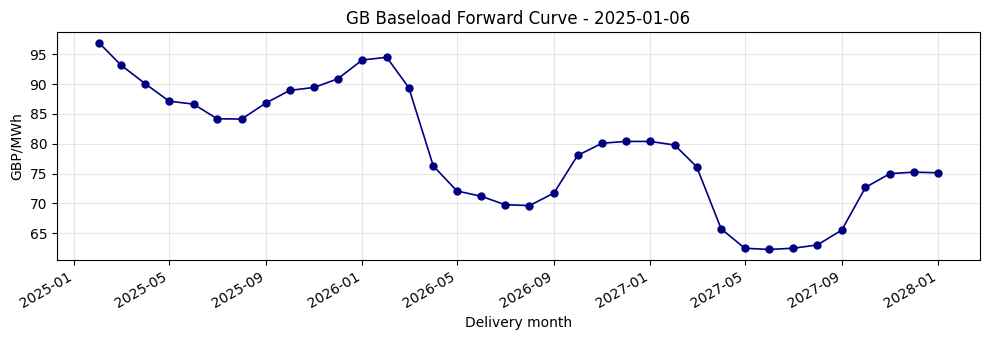

In [14]:
# Choose the curve date you want to inspect.
# If the exact date is not available, the latest available date on/before it is used.
curve_as_of = pd.Timestamp('2025-01-06')

available_dates = df_fwd['as_of_date'].drop_duplicates().sort_values().reset_index(drop=True)
pos = available_dates.searchsorted(curve_as_of, side='right') - 1
if pos < 0:
    raise ValueError(f'No forward curve available on or before {curve_as_of.date()}')

as_of = available_dates.iloc[pos]
bl_curve = (
    df_fwd
    .loc[(df_fwd['type'] == 'baseload') & (df_fwd['as_of_date'] == as_of)]
    .sort_values('delivery_start')
    .reset_index(drop=True)
)

print(f'Baseload forward curve as of {as_of.date()} ({len(bl_curve)} contracts)')
display(bl_curve[['contract', 'delivery_start', 'delivery_end', 'price_gbp_mwh']])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(bl_curve['delivery_start'], bl_curve['price_gbp_mwh'], 'o-', color='navy', ms=5, lw=1.2)
ax.set(
    title=f'GB Baseload Forward Curve - {as_of.date()}',
    xlabel='Delivery month',
    ylabel='GBP/MWh',
)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()